<a href="https://colab.research.google.com/github/Natassiam/machineLearning/blob/nb/NBayes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
from sklearn.datasets import fetch_20newsgroups
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score, f1_score

In [ ]:

def calcular_probabilidade_a_priori(y_train):
    total_docs = len(y_train)
    classes, counts = np.unique(y_train, return_counts=True)
    probabilidade_a_priori = counts / total_docs
    return probabilidade_a_priori

In [ ]:

# Função para calcular a probabilidade condicional (Multinomial)
def calcular_probabilidade_condicional_multinomial(X_train, y_train, classes, alpha=1):
    probabilidade_condicional = np.zeros((len(classes), X_train.shape[1])) + alpha
    for c in range(len(classes)):
        docs_idx = np.where(y_train == classes[c])[0]
        X_c = X_train[docs_idx]
        contagem_palavras = X_c.sum(axis=0)
        probabilidade_condicional[c, :] += np.asarray(contagem_palavras).flatten()
        total_palavras_classe = probabilidade_condicional[c].sum()
        probabilidade_condicional[c, :] /= total_palavras_classe
    return np.log(probabilidade_condicional)

In [ ]:
# Função para calcular a probabilidade condicional (Bernoulli)
def calcular_probabilidade_condicional_bernoulli(X_train, y_train, classes, alpha=1):
    probabilidade_condicional = np.zeros((len(classes), X_train.shape[1])) + alpha
    for c in range(len(classes)):
        docs_idx = np.where(y_train == classes[c])[0]
        X_c = X_train[docs_idx]
        # Convertendo para binário (presença ou ausência de palavras)
        X_c_binario = (X_c > 0).astype(int)
        contagem_palavras = X_c_binario.sum(axis=0)
        probabilidade_condicional[c, :] += np.asarray(contagem_palavras).flatten()
        total_docs_classe = X_c_binario.shape[0]
        probabilidade_condicional[c, :] /= total_docs_classe
    return np.log(probabilidade_condicional)

In [ ]:
# Função para calcular a probabilidade condicional (Gaussian)
def calcular_probabilidade_condicional_gaussian(X_train, y_train, classes):
    probabilidade_condicional = np.zeros((len(classes), X_train.shape[1], 2))  # Média e desvio padrão
    for c in range(len(classes)):
        docs_idx = np.where(y_train == classes[c])[0]
        X_c = X_train[docs_idx]

        # Convertendo para denso para cálculo de média e desvio padrão
        X_c_dense = X_c.toarray()  # Converte para denso
        media = X_c_dense.mean(axis=0)
        desvio_padrao = X_c_dense.std(axis=0)

        # Evitar divisão por zero (desvio padrão zero)
        desvio_padrao = np.maximum(desvio_padrao, 1e-10)  # Adiciona uma pequena constante

        probabilidade_condicional[c, :, 0] = media
        probabilidade_condicional[c, :, 1] = desvio_padrao
    return probabilidade_condicional

In [ ]:
# Função de predição para os 3 modelos
def prever(X_test, probabilidade_a_priori, probabilidade_condicional, modelo):
    if modelo == 'multinomial':
        scores = X_test.dot(probabilidade_condicional.T) + np.log(probabilidade_a_priori)
    elif modelo == 'bernoulli':
        scores = X_test.dot(probabilidade_condicional.T) + np.log(probabilidade_a_priori)
    elif modelo == 'gaussian':
        # Calcular pontuação para o modelo Gaussiano
        scores = np.zeros((X_test.shape[0], len(probabilidade_a_priori)))
        for c in range(len(probabilidade_a_priori)):
            media = probabilidade_condicional[c, :, 0]
            desvio_padrao = probabilidade_condicional[c, :, 1]
            # Calcular a probabilidade gaussiana para cada palavra no teste
            prob = -0.5 * np.sum(np.log(2 * np.pi * desvio_padrao**2)) - 0.5 * np.sum(((X_test.toarray() - media) ** 2) / (desvio_padrao**2), axis=1)
            scores[:, c] = prob + np.log(probabilidade_a_priori[c])
    return np.argmax(scores, axis=1)

In [ ]:
# Função principal para treinamento e predição
def treinar_e_predizer(X_train, y_train, X_test, modelo, alpha=1):
    # Calcular a probabilidade a priori
    probabilidade_a_priori = calcular_probabilidade_a_priori(y_train)
    classes = np.unique(y_train)

    # Calcular a probabilidade condicional conforme o modelo
    if modelo == 'multinomial':
        probabilidade_condicional = calcular_probabilidade_condicional_multinomial(X_train, y_train, classes, alpha)
    elif modelo == 'bernoulli':
        probabilidade_condicional = calcular_probabilidade_condicional_bernoulli(X_train, y_train, classes, alpha)
    elif modelo == 'gaussian':
        probabilidade_condicional = calcular_probabilidade_condicional_gaussian(X_train, y_train, classes)

    # Previsão nos dados de teste
    return prever(X_test, probabilidade_a_priori, probabilidade_condicional, modelo)


In [ ]:
# Carregar o conjunto de dados 20 Newsgroups
data = fetch_20newsgroups(subset='all')

# Vetorização dos dados de texto usando CountVectorizer
vectorizer = CountVectorizer(stop_words='english', max_features=5000)
X = vectorizer.fit_transform(data.data)

In [ ]:
# Dividir os dados em treinamento e teste
X_train, X_test, y_train, y_test = train_test_split(X, data.target, test_size=0.3, random_state=42)

# Treinamento e predição com o modelo Multinomial Naive Bayes
y_pred_multinomial = treinar_e_predizer(X_train, y_train, X_test, modelo='multinomial')

# Treinamento e predição com o modelo Bernoulli Naive Bayes
y_pred_bernoulli = treinar_e_predizer(X_train, y_train, X_test, modelo='bernoulli')

# Treinamento e predição com o modelo Gaussian Naive Bayes
y_pred_gaussian = treinar_e_predizer(X_train, y_train, X_test, modelo='gaussian')

In [ ]:
f1_multinomial = f1_score(y_test, y_pred_multinomial, average='weighted')
f1_bernoulli = f1_score(y_test, y_pred_bernoulli, average='weighted')
f1_gaussian = f1_score(y_test, y_pred_gaussian, average='weighted')

print("F1-Score do Modelo Multinomial Naive Bayes:", f1_multinomial)
print("F1-Score do Modelo Bernoulli Naive Bayes:", f1_bernoulli)
print("F1-Score do Modelo Gaussian Naive Bayes:", f1_gaussian)


if f1_multinomial >= f1_bernoulli and f1_multinomial >= f1_gaussian:
    best_model = 'Multinomial Naive Bayes'
elif f1_bernoulli >= f1_multinomial and f1_bernoulli >= f1_gaussian:
    best_model = 'Bernoulli Naive Bayes'
else:
    best_model = 'Gaussian Naive Bayes'

print("O melhor modelo baseado no F1-Score é:", best_model)

F1-Score do Modelo Multinomial Naive Bayes: 0.8056911888649226
F1-Score do Modelo Bernoulli Naive Bayes: 0.7729935877045282
F1-Score do Modelo Gaussian Naive Bayes: 0.661074252554158
O melhor modelo baseado no F1-Score é: Multinomial Naive Bayes


In [ ]:
# Avaliar a acurácia de cada modelo
acuracia_multinomial = accuracy_score(y_test, y_pred_multinomial)
acuracia_bernoulli = accuracy_score(y_test, y_pred_bernoulli)
acuracia_gaussian = accuracy_score(y_test, y_pred_gaussian)

# Exibir as acurácias
print("Acurácia do Modelo Multinomial Naive Bayes:", acuracia_multinomial)
print("Acurácia do Modelo Bernoulli Naive Bayes:", acuracia_bernoulli)
print("Acurácia do Modelo Gaussian Naive Bayes:", acuracia_gaussian)

# Escolher o melhor modelo com base na acurácia
if acuracia_multinomial >= acuracia_bernoulli and acuracia_multinomial >= acuracia_gaussian:
    best_model = 'Multinomial Naive Bayes'
elif acuracia_bernoulli >= acuracia_multinomial and acuracia_bernoulli >= acuracia_gaussian:
    best_model = 'Bernoulli Naive Bayes'
else:
    best_model = 'Gaussian Naive Bayes'

print("O melhor modelo é:", best_model)


Acurácia do Modelo Multinomial Naive Bayes: 0.8185355500530598
Acurácia do Modelo Bernoulli Naive Bayes: 0.7709586133710647
Acurácia do Modelo Gaussian Naive Bayes: 0.6609480014149275
O melhor modelo é: Multinomial Naive Bayes


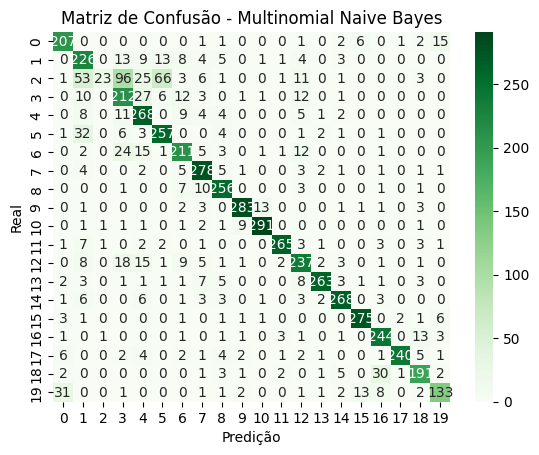

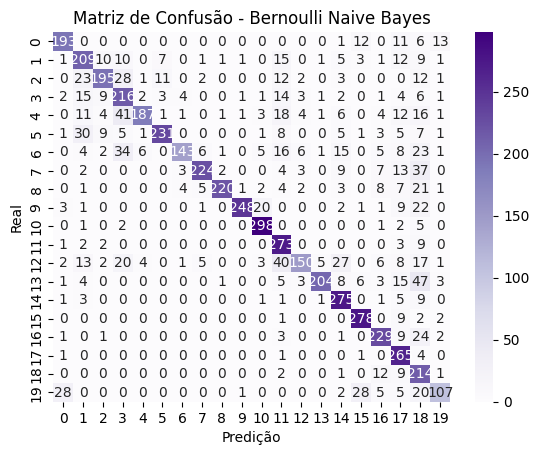

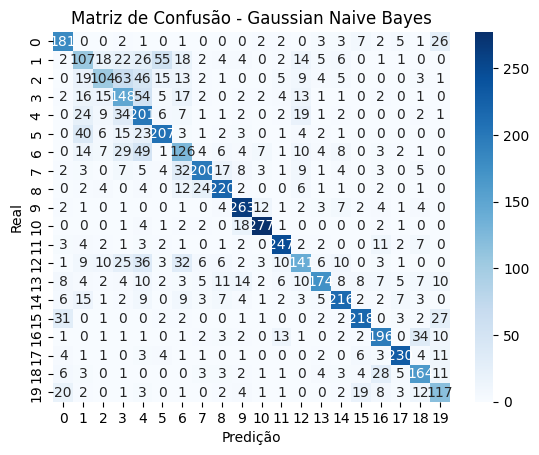

In [ ]:

# Matriz de confusão para o modelo Multinomial
cm_multinomial = confusion_matrix(y_test, y_pred_multinomial)
sns.heatmap(cm_multinomial, annot=True, fmt="d", cmap="Greens")
plt.title('Matriz de Confusão - Multinomial Naive Bayes')
plt.xlabel('Predição')
plt.ylabel('Real')
plt.show()


# Matriz de confusão para o modelo Bernoulli
cm_bernoulli = confusion_matrix(y_test, y_pred_bernoulli)
sns.heatmap(cm_bernoulli, annot=True, fmt="d", cmap="Purples")
plt.title('Matriz de Confusão - Bernoulli Naive Bayes')
plt.xlabel('Predição')
plt.ylabel('Real')
plt.show()

# Matriz de confusão para o modelo Gaussiano
cm_gaussian = confusion_matrix(y_test, y_pred_gaussian)
sns.heatmap(cm_gaussian, annot=True, fmt="d", cmap="Blues")
plt.title('Matriz de Confusão - Gaussian Naive Bayes')
plt.xlabel('Predição')
plt.ylabel('Real')
plt.show()


Acurácia do Modelo Multinomial Naive Bayes: 0.8185355500530598


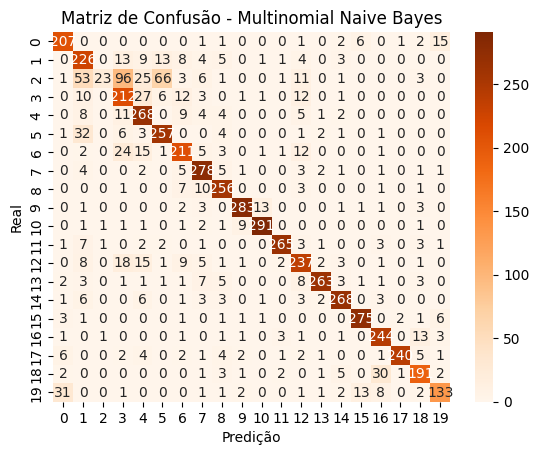

In [ ]:
# Treinamento e predição com o melhor modelo
y_pred_multinomial = treinar_e_predizer(X_train, y_train, X_test, modelo='multinomial')

# Avaliação de desempenho
print("Acurácia do Modelo Multinomial Naive Bayes:", accuracy_score(y_test, y_pred_multinomial))

# Matriz de confusão
cm_multinomial = confusion_matrix(y_test, y_pred_multinomial)
sns.heatmap(cm_multinomial, annot=True, fmt="d", cmap="Oranges")
plt.title('Matriz de Confusão - Multinomial Naive Bayes')
plt.xlabel('Predição')
plt.ylabel('Real')
plt.show()


In [ ]:
print("Classification Report - Multinomial Naive Bayes")
print(classification_report(y_test, y_pred_multinomial))

Classification Report - Multinomial Naive Bayes
              precision    recall  f1-score   support

           0       0.81      0.88      0.84       236
           1       0.62      0.79      0.70       287
           2       0.88      0.08      0.15       290
           3       0.55      0.74      0.63       285
           4       0.71      0.86      0.78       312
           5       0.74      0.83      0.78       308
           6       0.77      0.76      0.77       276
           7       0.83      0.91      0.87       304
           8       0.86      0.92      0.89       279
           9       0.94      0.92      0.93       308
          10       0.94      0.94      0.94       309
          11       0.96      0.91      0.94       290
          12       0.77      0.78      0.78       304
          13       0.95      0.88      0.91       300
          14       0.91      0.90      0.91       297
          15       0.93      0.94      0.94       292
          16       0.82      0.90